# ファイルの目的

adata

AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced'
    obsp: 'distances', 'connectivities'


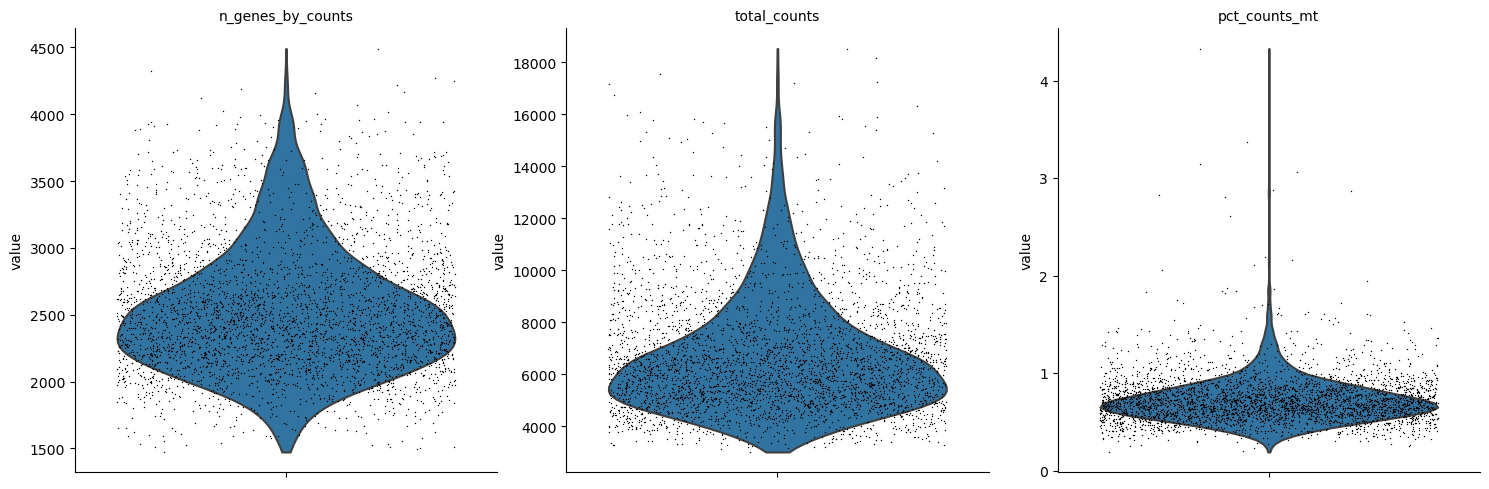

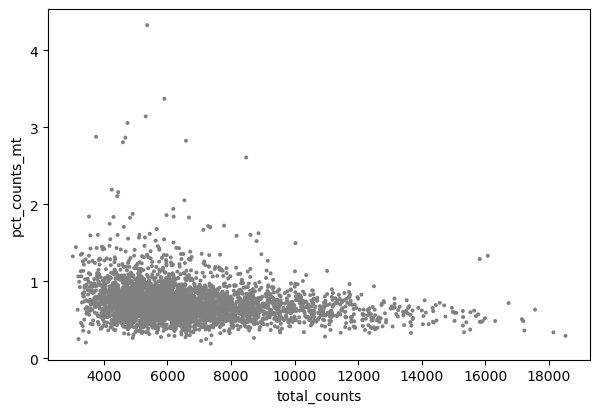

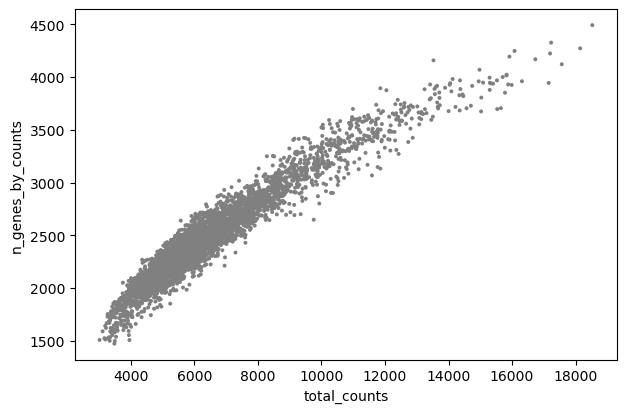

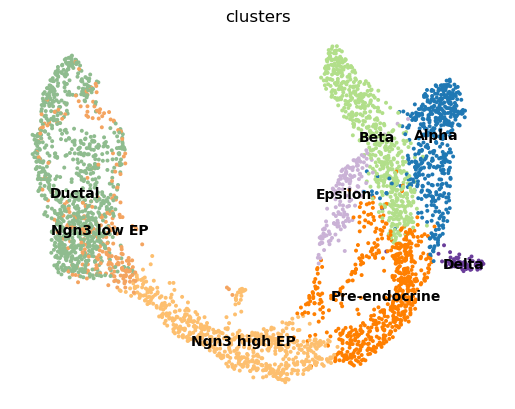

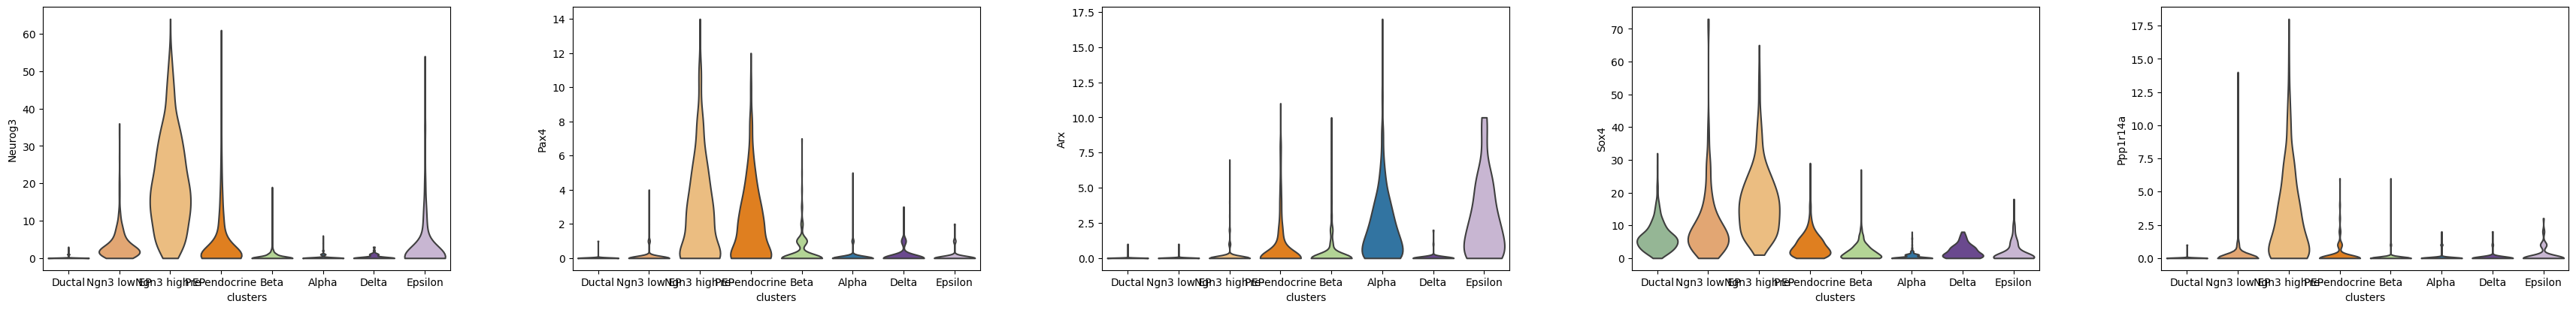

In [25]:
#!/usr/bin/env python
# -------------------------------------------
#  pancreas_qc_paga_minimal_fix.py
#
#  必要最小限:
#    • QC 可視化 (violin / scatter)
#    • PAGA クラスタ接続性 + UMAP
#    • マーカー遺伝子の violin plot
#
#  velocity・AnnData 保存など余計な処理は一切しない
# -------------------------------------------
import scanpy as sc
import scvelo as scv
import pandas as pd

# ── 0. pandas ≥2.0 の set_option エラー回避 ──────────────────
try:
    pd.set_option("mode.use_inf_as_null", False)
except (KeyError, ValueError):
    # オプションが無ければ動的に登録
    import pandas._config.config as _cfg
    _cfg.register_option("mode.use_inf_as_null", False)
    pd.set_option("mode.use_inf_as_null", False)

# ── 1. 描画関連設定 ────────────────────────────────
scv.settings.presenter_view = True          # 描画後に自動保存
scv.settings.figdir        = "scvelo_plots" # PDF 出力先

# ── 2. データ読み込み ───────────────────────────────
adata = scv.datasets.pancreas()             # 既存 PCA・UMAP 付き
print(adata)

# ── 3. QC メトリクス & プロット ─────────────────────
adata.var["mt"] = adata.var_names.str.startswith("mt-")
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt"],
    percent_top=None,
    log1p=False,
    inplace=True,
)

qc_keys = ["n_genes_by_counts", "total_counts", "pct_counts_mt"]
sc.pl.violin(adata, qc_keys, jitter=0.4, multi_panel=True, save="_qc_violin.pdf")
sc.pl.scatter(adata, x="total_counts",      y="pct_counts_mt",    save="_qc_scatter_counts_mt.pdf")
sc.pl.scatter(adata, x="total_counts",      y="n_genes_by_counts", save="_qc_scatter_counts_genes.pdf")


# PAGA 位置を初期値として再配置した UMAP
sc.pl.umap(adata, color="clusters", frameon=False, legend_loc="on data", save="_umap_clusters.pdf")

# ── 5. マーカー遺伝子 Violin ────────────────────────
marker_genes = ["Neurog3", "Pax4", "Arx", "Sox4", "Ppp1r14a"]
sc.pl.violin(adata, keys=marker_genes, groupby="clusters", stripplot=False, multi_panel=True, save="_marker_genes.pdf")


In [26]:
adata = scv.datasets.pancreas()             # 既存 PCA・UMAP 付き
print(adata)


AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced'
    obsp: 'distances', 'connectivities'


<3696x27998 sparse matrix of type '<class 'numpy.float32'>'
	with 9298890 stored elements in Compressed Sparse Row format>

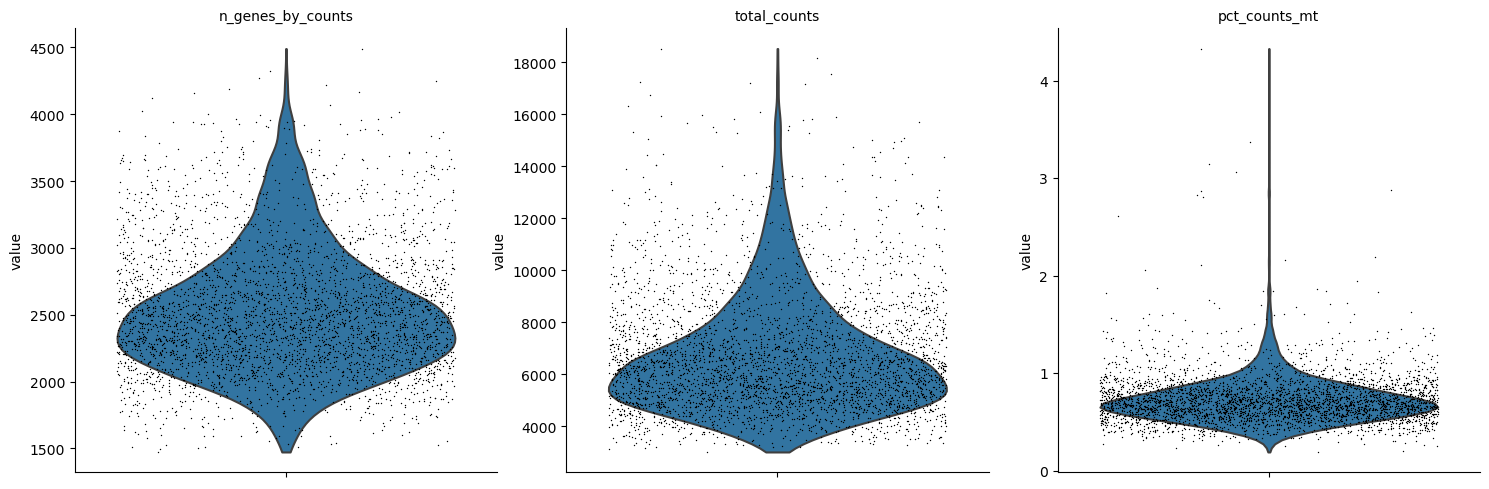

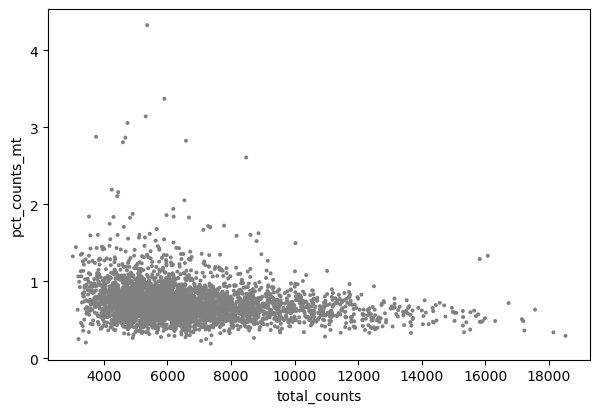

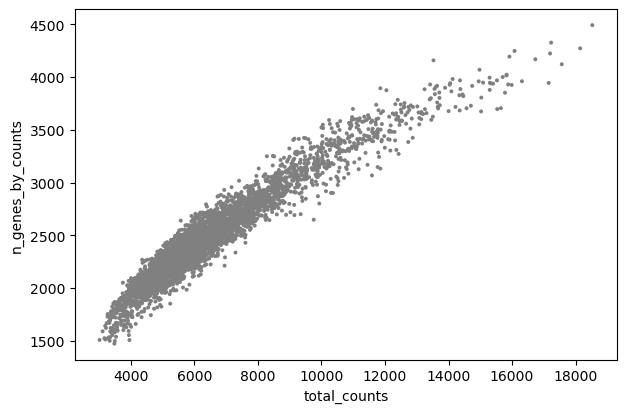

In [29]:
adata.X = adata.layers["spliced"]
# ── 3. QC メトリクス & プロット ─────────────────────
adata.var["mt"] = adata.var_names.str.startswith("mt-")
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt"],
    percent_top=None,
    log1p=False,
    inplace=True,
)

qc_keys = ["n_genes_by_counts", "total_counts", "pct_counts_mt"]
sc.pl.violin(adata, qc_keys, jitter=0.4, multi_panel=True)#, save="_qc_violin.pdf")
sc.pl.scatter(adata, x="total_counts",      y="pct_counts_mt")#,    save="_qc_scatter_counts_mt.pdf")
sc.pl.scatter(adata, x="total_counts",      y="n_genes_by_counts")#, save="_qc_scatter_counts_genes.pdf")

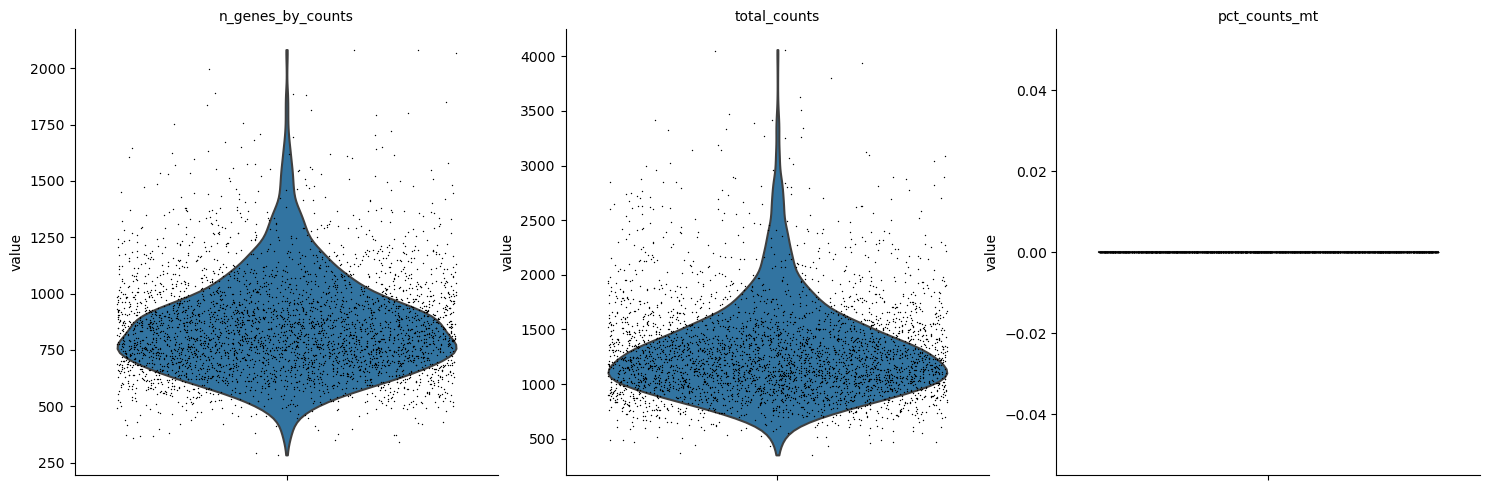

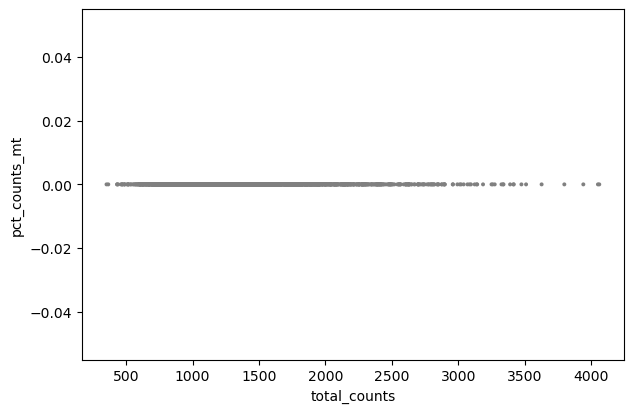

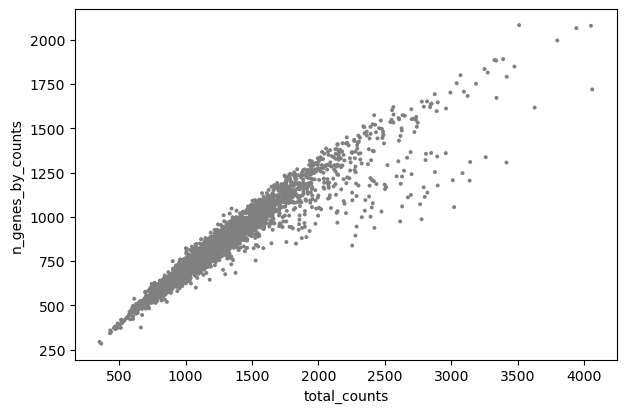

In [30]:
adata.X = adata.layers["unspliced"]
# ── 3. QC メトリクス & プロット ─────────────────────
adata.var["mt"] = adata.var_names.str.startswith("mt-")
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt"],
    percent_top=None,
    log1p=False,
    inplace=True,
)

qc_keys = ["n_genes_by_counts", "total_counts", "pct_counts_mt"]
sc.pl.violin(adata, qc_keys, jitter=0.4, multi_panel=True)#, save="_qc_violin.pdf")
sc.pl.scatter(adata, x="total_counts",      y="pct_counts_mt")#,    save="_qc_scatter_counts_mt.pdf")
sc.pl.scatter(adata, x="total_counts",      y="n_genes_by_counts")#, save="_qc_scatter_counts_genes.pdf")